In [2]:
import pandas as pd
import numpy as np
import torch
from transformers import AutoTokenizer, AutoModelForTokenClassification
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
from sklearn.metrics import classification_report, confusion_matrix
from tqdm.auto import tqdm
from sklearn.metrics import classification_report
import warnings
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

In [3]:
MODEL_PATH = "best_ml_model" 

model = AutoModelForTokenClassification.from_pretrained(MODEL_PATH)
tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)
model.eval()

# Получаем label mapping
id2label = model.config.id2label
label2id = model.config.label2id

print(f"Model loaded from {device}")
print(f"Labels: {len(id2label)}")
print(f"Labels: {list(id2label.values())[:10]}...")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Model loaded from cuda
Labels: 9
Labels: ['O', 'B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER']...


In [4]:
import ast

df = pd.read_csv(r"data\ner_dataset.csv")

def to_sentence_level(df_split):
    g = df_split.groupby("sentence_id", sort=False)
    return pd.DataFrame({
        "sentence_id": g.size().index,
        "tokens": g["token"].apply(list).values,
        "ner_tags": g["tag"].apply(list).values,
        "language": g["language"].first().values,
        "split": g["split"].first().values,
    })

def ensure_list(x):
    if isinstance(x, list): return x
    if pd.isna(x): return None
    if isinstance(x, str):
        x = x.strip()
        if x.startswith("[") and x.endswith("]"):
            try: return ast.literal_eval(x)
            except: return None
        return [x]
    return None

sent_df = to_sentence_level(df)
sent_df["tokens"] = sent_df["tokens"].apply(ensure_list)
sent_df["ner_tags"] = sent_df["ner_tags"].apply(ensure_list)
sent_df = sent_df.dropna(subset=["tokens", "ner_tags"]).reset_index(drop=True)
sent_df = sent_df[sent_df["tokens"].str.len() == sent_df["ner_tags"].str.len()].reset_index(drop=True)

test_df = sent_df[sent_df["split"] == "test"][["tokens", "ner_tags", "language"]].reset_index(drop=True)

print(f"Test set: {len(test_df)} sentences")

Test set: 4251 sentences


In [5]:
def predict_ner(tokens, return_probs=False):
    tokens = [str(t) for t in tokens]
    
    encoding = tokenizer(
        tokens,
        is_split_into_words=True,
        return_tensors="pt",
        truncation=True,
        max_length=128
    ).to(device)
    
    with torch.no_grad():
        outputs = model(**encoding)
        predictions = outputs.logits.argmax(-1).squeeze().cpu().numpy()
        if return_probs:
            probs = torch.softmax(outputs.logits, dim=-1).squeeze().cpu().numpy()
    
    word_ids = encoding.word_ids()
    aligned_predictions = []
    aligned_probs = [] if return_probs else None
    
    prev_word_id = None
    for i, word_id in enumerate(word_ids):
        if word_id is None:
            continue
        if word_id != prev_word_id:
            aligned_predictions.append(id2label[predictions[i]])
            if return_probs:
                aligned_probs.append(probs[i])
        prev_word_id = word_id
    
    if return_probs:
        return aligned_predictions, aligned_probs
    return aligned_predictions

test_tokens = ["John", "lives", "in", "New", "York"]
preds = predict_ner(test_tokens)
print(f"\nPrediction test:")
for token, pred in zip(test_tokens, preds):
    print(f"   {token:15} -> {pred}")


Prediction test:
   John            -> B-PER
   lives           -> O
   in              -> O
   New             -> B-LOC
   York            -> I-LOC


In [6]:
print("Getting prediction on test set...")

all_predictions = []
all_true_labels = []
all_tokens_list = []

for idx in tqdm(range(len(test_df))):
    tokens = test_df.iloc[idx]["tokens"]
    true_labels = test_df.iloc[idx]["ner_tags"]
    
    if not isinstance(tokens, list) or len(tokens) == 0:
        continue
    
    predictions = predict_ner(tokens)
    
    min_len = min(len(predictions), len(true_labels))
    
    all_predictions.extend(predictions[:min_len])
    all_true_labels.extend(true_labels[:min_len])
    all_tokens_list.extend(tokens[:min_len])

print(f"Got {len(all_predictions)} predictions")

Getting prediction on test set...


  0%|          | 0/4251 [00:00<?, ?it/s]

Got 62704 predictions


In [7]:
report = classification_report(all_true_labels, all_predictions, zero_division=0)
print("CLASSIFICATION REPORT:")
print("="*80)
print(report)

with open("classification_report.txt", "w") as f:
    f.write(report)
print("\nReport saved to classification_report.txt")

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

       B-LOC       0.97      0.97      0.97      1642
      B-MISC       0.97      0.95      0.96      1403
       B-ORG       0.92      0.94      0.93      1316
       B-PER       0.98      0.98      0.98      1536
       I-LOC       0.90      0.91      0.90       286
      I-MISC       0.96      0.95      0.95      1237
       I-ORG       0.90      0.93      0.91       970
       I-PER       0.98      0.98      0.98      1129
           O       1.00      1.00      1.00     53185

    accuracy                           0.99     62704
   macro avg       0.95      0.96      0.95     62704
weighted avg       0.99      0.99      0.99     62704


Report saved to classification_report.txt


In [8]:
unique_labels = sorted(set(all_true_labels + all_predictions))
entity_labels = [l for l in unique_labels if l != 'O']

print(f"\nTypes of entities found: {len(entity_labels)}")
print(f"Types: {entity_labels[:20]}..." if len(entity_labels) > 20 else f"   Типы: {entity_labels}")

true_counter = Counter(all_true_labels)
pred_counter = Counter(all_predictions)

print("\nTop 10 most frequent tags:")
for label, count in true_counter.most_common(10):
    pred_count = pred_counter[label]
    print(f"   {label:20} True: {count:6,}  Pred: {pred_count:6,}")


Types of entities found: 8
   Типы: ['B-LOC', 'B-MISC', 'B-ORG', 'B-PER', 'I-LOC', 'I-MISC', 'I-ORG', 'I-PER']

Top 10 most frequent tags:
   O                    True: 53,185  Pred: 53,143
   B-LOC                True:  1,642  Pred:  1,644
   B-PER                True:  1,536  Pred:  1,539
   B-MISC               True:  1,403  Pred:  1,384
   B-ORG                True:  1,316  Pred:  1,341
   I-MISC               True:  1,237  Pred:  1,229
   I-PER                True:  1,129  Pred:  1,134
   I-ORG                True:    970  Pred:  1,000
   I-LOC                True:    286  Pred:    290


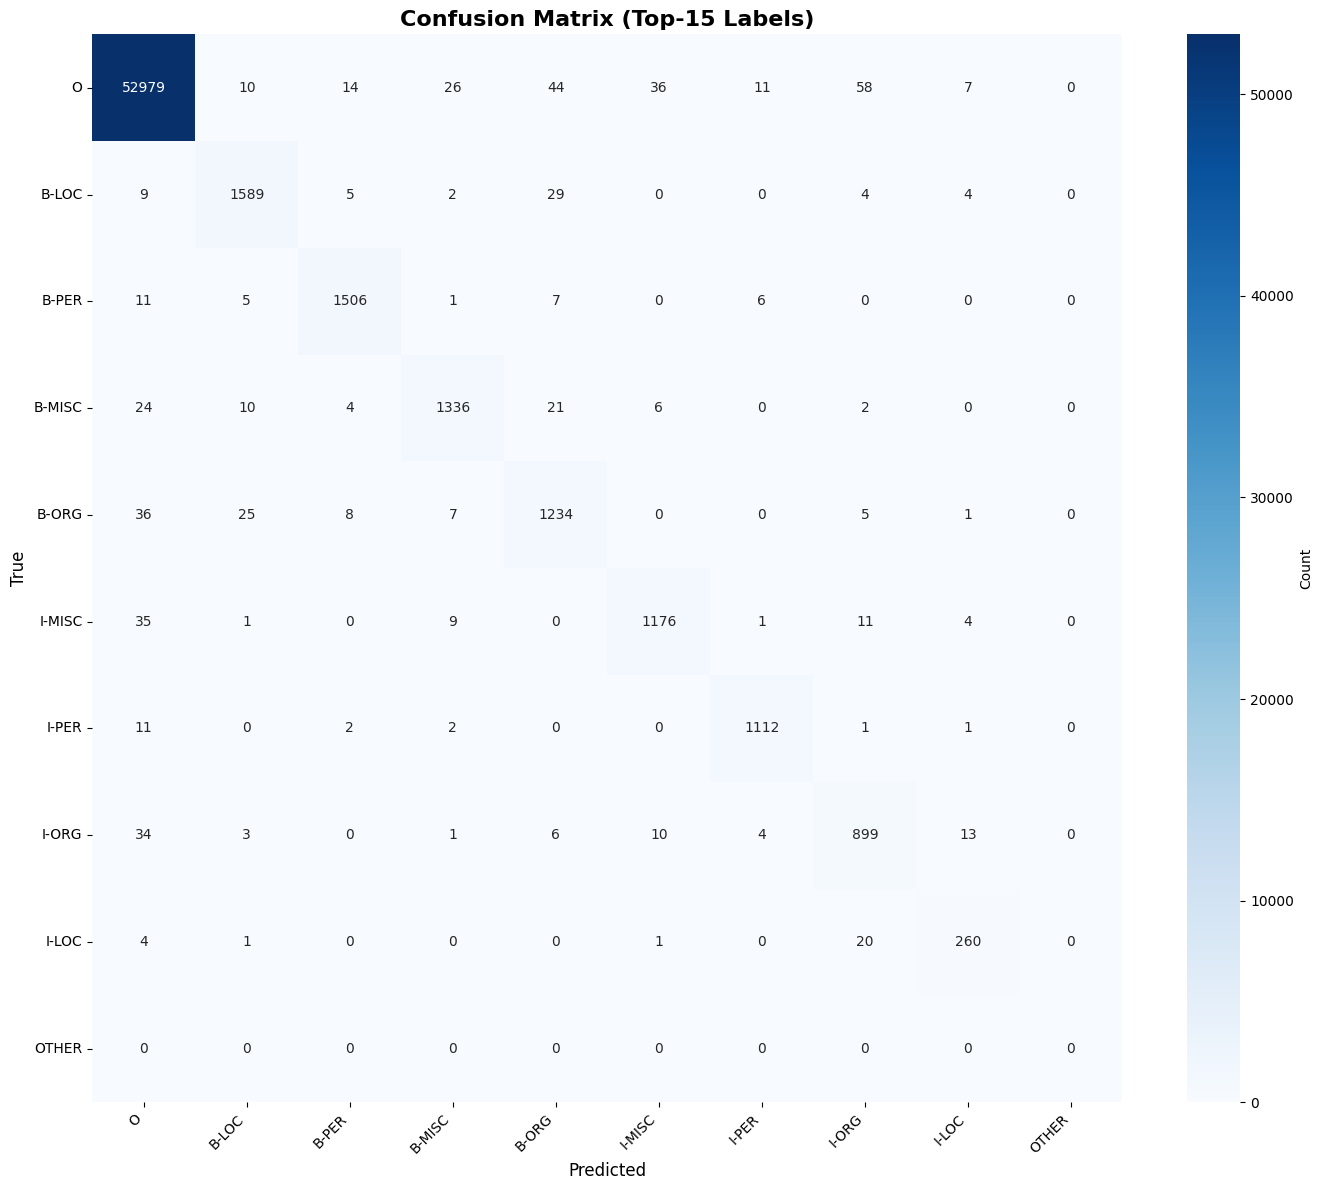

Confusion matrix saved: confusion_matrix.png


In [9]:
top_labels = [label for label, _ in true_counter.most_common(15)]

filtered_true = [l if l in top_labels else 'OTHER' for l in all_true_labels]
filtered_pred = [l if l in top_labels else 'OTHER' for l in all_predictions]

top_labels_with_other = top_labels + ['OTHER']

cm = confusion_matrix(filtered_true, filtered_pred, labels=top_labels_with_other)

plt.figure(figsize=(14, 12))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=top_labels_with_other, 
            yticklabels=top_labels_with_other,
            cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix (Top-15 Labels)', fontsize=16, fontweight='bold')
plt.xlabel('Predicted', fontsize=12)
plt.ylabel('True', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Confusion matrix saved: confusion_matrix.png")

In [10]:
errors = []
for i, (true, pred, token) in enumerate(zip(all_true_labels, all_predictions, all_tokens_list)):
    if true != pred:
        errors.append({
            'token': token,
            'true': true,
            'pred': pred,
            'index': i
        })

errors_df = pd.DataFrame(errors)

print(f"\nTotal errors: {len(errors):,} из {len(all_true_labels):,} токенов")
print(f"Accuracy: {(1 - len(errors)/len(all_true_labels))*100:.2f}%")

error_types = errors_df.groupby(['true', 'pred']).size().sort_values(ascending=False)

print("\nTop-10 types of error:")
print("="*60)
for (true, pred), count in error_types.head(20).items():
    print(f"   {true:20} → {pred:20} : {count:5,} раз")

# Сохраняем
errors_df.to_csv('errors_analysis.csv', index=False)
print("\nError analysis saved: errors_analysis.csv")


Total errors: 613 из 62,704 токенов
Accuracy: 99.02%

Top-10 types of error:
   O                    → I-ORG                :    58 раз
   O                    → B-ORG                :    44 раз
   B-ORG                → O                    :    36 раз
   O                    → I-MISC               :    36 раз
   I-MISC               → O                    :    35 раз
   I-ORG                → O                    :    34 раз
   B-LOC                → B-ORG                :    29 раз
   O                    → B-MISC               :    26 раз
   B-ORG                → B-LOC                :    25 раз
   B-MISC               → O                    :    24 раз
   B-MISC               → B-ORG                :    21 раз
   I-LOC                → I-ORG                :    20 раз
   O                    → B-PER                :    14 раз
   I-ORG                → I-LOC                :    13 раз
   I-PER                → O                    :    11 раз
   B-PER                → O          

In [11]:
print("\nExamples of successful predictions:\n")
print("="*80)

success_count = 0
for idx in range(len(test_df)):
    if success_count >= 10:  
        break
    
    tokens = test_df.iloc[idx]["tokens"]
    true_labels = test_df.iloc[idx]["ner_tags"]
    
    if not isinstance(tokens, list):
        continue
    
    predictions = predict_ner(tokens)
    
    min_len = min(len(predictions), len(true_labels))
    has_entities = any(l != 'O' for l in true_labels[:min_len])
    all_correct = all(p == t for p, t in zip(predictions[:min_len], true_labels[:min_len]))
    
    if has_entities and all_correct:
        success_count += 1
        print(f"\nExample {success_count}:")
        print(f"Sentence: {' '.join(tokens[:min_len])}")
        print(f"\nToken            True Label       Prediction")
        print("-" * 60)
        for token, true, pred in zip(tokens[:min_len], true_labels[:min_len], predictions[:min_len]):
            if true != 'O':
                print(f"{token:15} {true:15} {pred:15} ✓")


Examples of successful predictions:


Example 1:
Sentence: Bonn has led efforts to protect public health after consumer confidence collapsed in March after a British report suggested humans could contract an illness similar to mad cow disease by eating contaminated beef .

Token            True Label       Prediction
------------------------------------------------------------
Bonn            B-LOC           B-LOC           ✓
British         B-MISC          B-MISC          ✓

Example 2:
Sentence: Germany imported 47,600 sheep from Britain last year , nearly half of total imports .

Token            True Label       Prediction
------------------------------------------------------------
Germany         B-LOC           B-LOC           ✓
Britain         B-LOC           B-LOC           ✓

Example 3:
Sentence: The growth was partly due to an increased number of Germans buying German cars abroad , while manufacturers said that domestic demand was weak , the federal office said .

Token     

In [14]:
print("\nExamples of failing predictions:\n")
print("="*80)

error_count = 0
for idx in range(len(test_df)):
    if error_count >= 15:  
        break
    
    tokens = test_df.iloc[idx]["tokens"]
    true_labels = test_df.iloc[idx]["ner_tags"]
    
    if not isinstance(tokens, list):
        continue
    
    predictions, probs = predict_ner(tokens, return_probs=True)
    
    min_len = min(len(predictions), len(true_labels))
    has_errors = any(p != t for p, t in zip(predictions[:min_len], true_labels[:min_len]))
    has_entities = any(l != 'O' for l in true_labels[:min_len])
    
    if has_errors and has_entities:
        error_count += 1
        print(f"\nExample of failure {error_count}:")
        print(f"Sentence: {' '.join(tokens[:min_len])}")
        print(f"\nToken            True Label       Prediction       Confidence")
        print("-" * 75)
        
        for i, (token, true, pred) in enumerate(zip(tokens[:min_len], true_labels[:min_len], predictions[:min_len])):
            if true != pred:
                conf = probs[i][label2id[pred]] if i < len(probs) else 0
                marker = "X" if true != 'O' else "🚨" 
                print(f"{token:15} {true:15} {pred:15} {conf:.3f}  {marker}")


Examples of failing predictions:


Example of failure 1:
Sentence: AD-DIYAR

Token            True Label       Prediction       Confidence
---------------------------------------------------------------------------
AD-DIYAR        B-ORG           B-LOC           0.793  X

Example of failure 2:
Sentence: 2. Eveningperformance 16-1 ( Chris Rutter )

Token            True Label       Prediction       Confidence
---------------------------------------------------------------------------
Eveningperformance B-PER           O               0.624  X

Example of failure 3:
Sentence: SOCCER - KEANE SIGNS FOUR-YEAR CONTRACT WITH MANCHESTER UNITED .

Token            True Label       Prediction       Confidence
---------------------------------------------------------------------------
MANCHESTER      B-LOC           B-ORG           0.999  X
UNITED          I-LOC           I-ORG           0.999  X

Example of failure 4:
Sentence: Hearts - Dave McPherson ( 44th )

Token            True Label      

In [15]:
if 'language' in test_df.columns:
    print("\nAnalysis by languages:\n")
    print("="*80)
    
    lang_results = defaultdict(lambda: {'correct': 0, 'total': 0})
    
    for idx in range(len(test_df)):
        tokens = test_df.iloc[idx]["tokens"]
        true_labels = test_df.iloc[idx]["ner_tags"]
        lang = test_df.iloc[idx].get("language", "unknown")
        
        if not isinstance(tokens, list):
            continue
        
        predictions = predict_ner(tokens)
        min_len = min(len(predictions), len(true_labels))
        
        for true, pred in zip(true_labels[:min_len], predictions[:min_len]):
            lang_results[lang]['total'] += 1
            if true == pred:
                lang_results[lang]['correct'] += 1
    
    print(f"{'Language':15} {'Accuracy':>10} {'Total tokens':>15}")
    print("-" * 45)
    for lang, stats in sorted(lang_results.items(), key=lambda x: x[1]['total'], reverse=True):
        acc = (stats['correct'] / stats['total'] * 100) if stats['total'] > 0 else 0
        print(f"{lang:15} {acc:>9.2f}% {stats['total']:>15,}")
else:
    print("\nInformation about languages is not available")


Analysis by languages:

Language          Accuracy    Total tokens
---------------------------------------------
ru                  99.30%          26,522
en                  98.90%          19,837
kaz                 98.72%          16,345
